# Lesson 4: Classification and Neural Networks

In Lesson 3, we predicted numbers - house prices, fuel efficiency. The model's output could be any value: $250,000, $347,821, anything on a continuous scale. That's **regression**.

Now we flip the question. Instead of "how much?" we're asking "which one?" Did this passenger survive? Is this email spam? Is this tumor benign or malignant? The answer isn't a number - it's a category. That's **classification**, and it's everywhere: every time your phone unlocks with your face, every time Gmail filters spam, every time a bank flags a suspicious transaction.

The good news: almost everything from L3 carries over. We still use gradient descent. We still have a training loop. We still start with random weights and optimize them. The changes are surprisingly small - a different output function (sigmoid instead of raw numbers) and a different loss function (cross-entropy instead of MSE). Same engine, different task.

By the end of this lesson, we'll also build our first **neural network** - a model that can learn patterns logistic regression can't. But first, let's see classification in action.

In [44]:
# Setup - run this first
from pathlib import Path
try:
    import google.colab
    DATA_PATH = Path('/content/data')
except ImportError:
    DATA_PATH = Path('../../../../data')

# Download creditcard dataset if not present (210MB)
credit_path = DATA_PATH / 'creditcard' / 'creditcard.csv'
if not credit_path.exists():
    print("Downloading credit card fraud dataset...")
    credit_path.parent.mkdir(parents=True, exist_ok=True)
    import urllib.request
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv',
        str(credit_path))
    print(f"Downloaded to {credit_path}")

print(f"Data path: {DATA_PATH}")

Data path: ../../../../data


In [45]:
# === VISUALIZATION HELPERS (click to expand) ===
# These functions create the visualizations used in this notebook.
# The code is hidden to keep focus on the ML concepts.

def plot_classification_problem(ages, fares, survived):
    """Show the fundamental classification problem: two groups that need separating."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = ['#e74c3c' if s == 0 else '#3498db' for s in survived]
    ax.scatter(ages, fares, c=colors, alpha=0.6, edgecolors='white', s=60)
    
    # Legend
    ax.scatter([], [], c='#3498db', s=60, label='Survived', edgecolors='white')
    ax.scatter([], [], c='#e74c3c', s=60, label='Died', edgecolors='white')
    ax.legend(loc='upper right', fontsize=12)
    
    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('Fare (ticket price)', fontsize=12)
    ax.set_title('The Classification Problem: Can You Separate These Groups?', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_manual_boundary(ages, fares, survived, slope=None, intercept=None):
    """Show what a decision boundary does - separate the space into regions."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    colors = ['#e74c3c' if s == 0 else '#3498db' for s in survived]
    ax.scatter(ages, fares, c=colors, alpha=0.6, edgecolors='white', s=60)
    
    if slope is not None and intercept is not None:
        # Draw the boundary line
        x_line = np.array([0, 80])
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'k--', linewidth=2, label='Decision Boundary')
        
        # Shade regions
        ax.fill_between(x_line, y_line, 600, alpha=0.1, color='blue', label='Predict: Survived')
        ax.fill_between(x_line, 0, y_line, alpha=0.1, color='red', label='Predict: Died')
    
    ax.set_xlim(0, 80)
    ax.set_ylim(0, 300)
    ax.set_xlabel('Age', fontsize=12)
    ax.set_ylabel('Fare (ticket price)', fontsize=12)
    ax.set_title('A Decision Boundary Divides the Space', fontsize=14)
    ax.legend(loc='upper right', fontsize=11)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_boundary_accuracy(ages, fares, survived, slope, intercept):
    """Show how a boundary classifies points and compute accuracy."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Predict based on boundary
    predicted = (fares > slope * ages + intercept).astype(int)
    correct = (predicted == survived)
    accuracy = correct.mean()
    
    # Left: show correct/incorrect
    for ax_idx, (ax, title) in enumerate([(axes[0], 'Correct Predictions'), 
                                           (axes[1], 'Incorrect Predictions')]):
        mask = correct if ax_idx == 0 else ~correct
        
        colors = ['#e74c3c' if s == 0 else '#3498db' for s in survived[mask]]
        ax.scatter(ages[mask], fares[mask], c=colors, alpha=0.7, edgecolors='white', s=60)
        
        x_line = np.array([0, 80])
        y_line = slope * x_line + intercept
        ax.plot(x_line, y_line, 'k--', linewidth=2)
        ax.fill_between(x_line, y_line, 600, alpha=0.1, color='blue')
        ax.fill_between(x_line, 0, y_line, alpha=0.1, color='red')
        
        ax.set_xlim(0, 80)
        ax.set_ylim(0, 300)
        ax.set_xlabel('Age', fontsize=12)
        ax.set_ylabel('Fare', fontsize=12)
        count = mask.sum()
        ax.set_title(f'{title}: {count} passengers ({count/len(survived):.0%})', fontsize=13)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'This boundary achieves {accuracy:.1%} accuracy', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return accuracy

def plot_survival_rates(data):
    """Show survival rates by different factors."""
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    # By sex
    survival_by_sex = data.groupby('Sex')['Survived'].mean()
    colors = ['#e74c3c' if x == 'female' else '#3498db' for x in survival_by_sex.index]
    axes[0].bar(survival_by_sex.index, survival_by_sex.values, color=colors)
    axes[0].set_ylabel('Survival Rate')
    axes[0].set_title('By Gender')
    axes[0].set_ylim(0, 1)
    for i, v in enumerate(survival_by_sex.values):
        axes[0].text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')
    
    # By class
    survival_by_class = data.groupby('Pclass')['Survived'].mean()
    axes[1].bar(['1st', '2nd', '3rd'], survival_by_class.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
    axes[1].set_ylabel('Survival Rate')
    axes[1].set_title('By Ticket Class')
    axes[1].set_ylim(0, 1)
    for i, v in enumerate(survival_by_class.values):
        axes[1].text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')
    
    # By age group
    data_copy = data.copy()
    data_copy['AgeGroup'] = pd.cut(data_copy['Age'], bins=[0, 12, 18, 35, 50, 100], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
    survival_by_age = data_copy.groupby('AgeGroup', observed=True)['Survived'].mean()
    axes[2].bar(range(len(survival_by_age)), survival_by_age.values, color='#9b59b6')
    axes[2].set_xticks(range(len(survival_by_age)))
    axes[2].set_xticklabels(survival_by_age.index, rotation=45)
    axes[2].set_ylabel('Survival Rate')
    axes[2].set_title('By Age Group')
    axes[2].set_ylim(0, 1)
    
    # Combined: Sex + Class
    survival_combined = data.groupby(['Sex', 'Pclass'])['Survived'].mean().unstack()
    x = np.arange(2)
    width = 0.25
    axes[3].bar(x - width, survival_combined[1], width, label='1st Class', color='#2ecc71')
    axes[3].bar(x, survival_combined[2], width, label='2nd Class', color='#f39c12')
    axes[3].bar(x + width, survival_combined[3], width, label='3rd Class', color='#e74c3c')
    axes[3].set_xticks(x)
    axes[3].set_xticklabels(['Female', 'Male'])
    axes[3].set_ylabel('Survival Rate')
    axes[3].set_title('Gender + Class Combined')
    axes[3].set_ylim(0, 1)
    axes[3].legend()
    
    plt.tight_layout()
    plt.show()

def plot_linear_regression_problem():
    """Show why linear regression fails for classification."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Left: Linear regression on binary data
    jitter_x = X_simple + np.random.normal(0, 0.05, len(X_simple))
    jitter_y = y_simple + np.random.normal(0, 0.05, len(y_simple))
    
    axes[0].scatter(jitter_x, jitter_y, alpha=0.3, c=y_simple, cmap='RdYlBu')
    
    x_line = np.linspace(-0.5, 1.5, 100)
    y_line = w * x_line + b
    axes[0].plot(x_line, y_line, 'r-', linewidth=2, label=f'y = {w:.2f}x + {b:.2f}')
    
    axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlim(-0.5, 1.5)
    axes[0].set_ylim(-0.3, 1.3)
    axes[0].set_xlabel('Is Male (0=Female, 1=Male)')
    axes[0].set_ylabel('Survived')
    axes[0].set_title('Linear Regression on Classification Data')
    axes[0].legend()
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['Female', 'Male'])
    
    # Right: What happens with extreme values
    ages = titanic['Age'].dropna().values
    survived = titanic.loc[titanic['Age'].notna(), 'Survived'].values
    
    age_mean = ages.mean()
    surv_mean = survived.mean()
    w_age = np.sum((ages - age_mean) * (survived - surv_mean)) / np.sum((ages - age_mean)**2)
    b_age = surv_mean - w_age * age_mean
    
    axes[1].scatter(ages, survived + np.random.normal(0, 0.03, len(survived)), alpha=0.3, c=survived, cmap='RdYlBu')
    
    x_ext = np.linspace(-20, 100, 100)
    y_ext = w_age * x_ext + b_age
    axes[1].plot(x_ext, y_ext, 'r-', linewidth=2, label='Linear regression')
    
    axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    axes[1].axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    axes[1].fill_between(x_ext, 1, 1.5, alpha=0.2, color='red', label='Invalid: > 1')
    axes[1].fill_between(x_ext, -0.5, 0, alpha=0.2, color='red', label='Invalid: < 0')
    
    axes[1].set_xlim(-20, 100)
    axes[1].set_ylim(-0.3, 1.3)
    axes[1].set_xlabel('Age')
    axes[1].set_ylabel('Predicted "Survival"')
    axes[1].set_title('Problem: Predictions Go Outside [0, 1]')
    axes[1].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

def plot_sigmoid():
    """Show the sigmoid function and how it creates a boundary."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    z = np.linspace(-10, 10, 200)
    s = sigmoid(z)
    
    # Left: The sigmoid curve
    axes[0].plot(z, s, 'b-', linewidth=2)
    axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    axes[0].axhline(y=0, color='gray', alpha=0.3)
    axes[0].axhline(y=1, color='gray', alpha=0.3)
    axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    
    axes[0].fill_between(z[z < 0], 0, s[z < 0], alpha=0.2, color='red')
    axes[0].fill_between(z[z > 0], s[z > 0], 1, alpha=0.2, color='blue')
    
    axes[0].annotate('z < 0 -> probability < 0.5\n-> predict Class 0', xy=(-6, 0.15), fontsize=10,
                     bbox=dict(boxstyle='round', facecolor='#ffcccc', alpha=0.8))
    axes[0].annotate('z > 0 -> probability > 0.5\n-> predict Class 1', xy=(2, 0.85), fontsize=10,
                     bbox=dict(boxstyle='round', facecolor='#cce5ff', alpha=0.8))
    axes[0].annotate('z = 0 is the\ndecision boundary!', xy=(0.3, 0.55), fontsize=10,
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))
    
    axes[0].set_xlabel('z (the linear combination)', fontsize=12)
    axes[0].set_ylabel('sigma(z) = probability', fontsize=12)
    axes[0].set_title('Sigmoid: Where z=0 Is the Decision Boundary', fontsize=13)
    axes[0].set_ylim(-0.1, 1.1)
    axes[0].grid(True, alpha=0.3)
    
    # Right: Compare linear vs sigmoid
    z2 = np.linspace(-3, 3, 100)
    axes[1].plot(z2, z2, 'r--', linewidth=2, label='Linear: y = z', alpha=0.7)
    axes[1].plot(z2, sigmoid(z2), 'b-', linewidth=2, label='Sigmoid: y = sigma(z)')
    axes[1].axhline(y=0, color='gray', alpha=0.3)
    axes[1].axhline(y=1, color='gray', alpha=0.3)
    axes[1].fill_between(z2, 0, 1, alpha=0.1, color='green', label='Valid probability range')
    
    axes[1].set_xlabel('z', fontsize=12)
    axes[1].set_ylabel('Output', fontsize=12)
    axes[1].set_title('Linear Goes Anywhere; Sigmoid Stays in [0, 1]', fontsize=13)
    axes[1].legend(loc='upper left')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_training_curves(train_losses, val_losses):
    """Plot training and validation loss curves."""
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss', color='#3498db')
    plt.plot(val_losses, label='Validation Loss', color='#e74c3c')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (Cross-Entropy)')
    plt.title('Logistic Regression Training')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_decision_boundary_logistic(X, y, w, b, title):
    """Plot decision boundary for logistic regression."""
    fig, ax = plt.subplots(figsize=(10, 8))
    
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = logistic_regression_predict(grid, w, b).reshape(xx.shape)
    
    contour = ax.contourf(xx, yy, probs, levels=50, cmap='RdYlBu', alpha=0.6)
    ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2, linestyles='--')
    
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='black', s=50, alpha=0.8)
    
    plt.colorbar(contour, ax=ax, label='P(Survived)')
    ax.set_xlabel('Age (normalized)')
    ax.set_ylabel('Fare (normalized)')
    ax.set_title(title)
    
    ax.annotate('Decision boundary\n(where P=0.5)', xy=(0, -0.5), fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def plot_comparison(X, y, w_log, b_log, mlp_model, title1, title2, acc1, acc2):
    """Compare logistic regression and MLP decision boundaries."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for ax, model_type, title, acc in [(axes[0], 'logistic', title1, acc1), 
                                        (axes[1], 'mlp', title2, acc2)]:
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
        grid = np.c_[xx.ravel(), yy.ravel()]
        
        if model_type == 'logistic':
            probs = logistic_regression_predict(grid, w_log, b_log).reshape(xx.shape)
        else:
            model_device = next(mlp_model.parameters()).device
            mlp_model.eval()
            with torch.no_grad():
                probs = mlp_model(torch.FloatTensor(grid).to(model_device)).cpu().numpy().reshape(xx.shape)
        
        contour = ax.contourf(xx, yy, probs, levels=50, cmap='RdYlBu', alpha=0.6)
        ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2, linestyles='--')
        ax.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlBu', edgecolors='black', s=50, alpha=0.8)
        
        plt.colorbar(contour, ax=ax, label='P(Survived)')
        ax.set_xlabel('Age (normalized)')
        ax.set_ylabel('Fare (normalized)')
        ax.set_title(f'{title}\n(Accuracy: {acc:.1%})')
    
    plt.tight_layout()
    plt.show()

def plot_relu():
    """Show the ReLU function and why non-linearity matters."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    x = np.linspace(-5, 5, 100)
    
    axes[0].plot(x, np.maximum(0, x), 'b-', linewidth=2)
    axes[0].axhline(y=0, color='gray', alpha=0.3)
    axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_xlabel('Input')
    axes[0].set_ylabel('Output')
    axes[0].set_title('ReLU: max(0, x)')
    axes[0].grid(True, alpha=0.3)
    axes[0].annotate('Negative -> 0', xy=(-3, 0.2), fontsize=11,
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[0].annotate('Positive -> unchanged', xy=(1.5, 3.5), fontsize=11,
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    axes[1].text(0.5, 0.8, 'Without ReLU:', fontsize=14, fontweight='bold',
                 transform=axes[1].transAxes, ha='center')
    axes[1].text(0.5, 0.65, 'Linear -> Linear = Linear', fontsize=12,
                 transform=axes[1].transAxes, ha='center', family='monospace')
    axes[1].text(0.5, 0.55, '(Still just a straight line!)', fontsize=11,
                 transform=axes[1].transAxes, ha='center', color='red')
    
    axes[1].text(0.5, 0.35, 'With ReLU:', fontsize=14, fontweight='bold',
                 transform=axes[1].transAxes, ha='center')
    axes[1].text(0.5, 0.2, 'Linear -> ReLU -> Linear = Non-linear', fontsize=12,
                 transform=axes[1].transAxes, ha='center', family='monospace')
    axes[1].text(0.5, 0.1, '(Can learn curves!)', fontsize=11,
                 transform=axes[1].transAxes, ha='center', color='green')
    
    axes[1].axis('off')
    axes[1].set_title('Why Non-linearity Matters')
    
    plt.tight_layout()
    plt.show()

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
DATA_PATH = Path("../../../../data")

## Demo 1: Medical Diagnosis

A doctor looks at a breast tissue sample and needs to decide: **benign or malignant?**

This is life-or-death classification. The model takes measurements of cell nuclei (radius, texture, smoothness, etc.) and predicts whether a tumor is cancerous.

Let's see how well a simple classifier can do this:

In [47]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the breast cancer dataset
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

print("Breast Cancer Wisconsin Dataset")
print("="*50)
print(f"Samples: {len(X)}")
print(f"Features: {len(cancer.feature_names)} measurements per sample")
print(f"Classes: {cancer.target_names}")
print(f"\nSample features: {cancer.feature_names[:5]}...")

Breast Cancer Wisconsin Dataset
Samples: 569
Features: 30 measurements per sample
Classes: ['malignant' 'benign']

Sample features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']...


30 features, two possible outcomes. Let's train a logistic regression classifier and see how it does:

In [48]:
# Train a classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"\nAccuracy: {accuracy:.1%}")
print(f"\nThis means: out of {len(X_test)} tissue samples, the model correctly")
print(f"identified {int(accuracy * len(X_test))} as benign or malignant.")

# Confusion matrix
cm = confusion_matrix(y_test, predictions)
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Malignant  Benign")
print(f"Actual Malignant    {cm[0,0]:3d}      {cm[0,1]:3d}")
print(f"       Benign       {cm[1,0]:3d}      {cm[1,1]:3d}")


Accuracy: 95.6%

This means: out of 114 tissue samples, the model correctly
identified 109 as benign or malignant.

Confusion Matrix:
                 Predicted
                 Malignant  Benign
Actual Malignant     39        4
       Benign         1       70


## Demo 2: Fraud Detection

A credit card company processes millions of transactions daily. Each one needs an instant decision: **legitimate or fraudulent?**

The challenge: fraud is rare (~0.2% of transactions), so the model must be very precise to avoid blocking legitimate purchases while still catching fraud.

In [49]:
# Load credit card fraud dataset
# Download: kaggle datasets download -d mlg-ulb/creditcardfraud
fraud_df = pd.read_csv(DATA_PATH / "creditcard" / "creditcard.csv")

print("Credit Card Fraud Dataset")
print("="*50)
print(f"Transactions: {len(fraud_df):,}")
print(f"Fraudulent: {fraud_df['Class'].sum():,} ({fraud_df['Class'].mean():.2%})")
print(f"Legitimate: {(fraud_df['Class']==0).sum():,}")
print(f"\nFeatures: {fraud_df.shape[1]-1} (anonymized for privacy)")

Credit Card Fraud Dataset
Transactions: 284,807
Fraudulent: 492 (0.17%)
Legitimate: 284,315

Features: 30 (anonymized for privacy)


In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score

# Use a sample for speed
fraud_sample = fraud_df.sample(n=20000, random_state=42)
X_fraud = fraud_sample.drop('Class', axis=1)
y_fraud = fraud_sample['Class']

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, random_state=42
)

# Train a fraud detector
fraud_model = RandomForestClassifier(n_estimators=50, random_state=42)
fraud_model.fit(X_train_f, y_train_f)

# Evaluate
fraud_preds = fraud_model.predict(X_test_f)
accuracy = accuracy_score(y_test_f, fraud_preds)
precision = precision_score(y_test_f, fraud_preds)
recall = recall_score(y_test_f, fraud_preds)

print(f"\nResults on test set:")
print(f"Accuracy: {accuracy:.1%}")
print(f"Precision: {precision:.1%} (of transactions flagged as fraud, how many actually were)")
print(f"Recall: {recall:.1%} (of actual fraud, how many did we catch)")


Results on test set:
Accuracy: 99.9%
Precision: 83.3% (of transactions flagged as fraud, how many actually were)
Recall: 71.4% (of actual fraud, how many did we catch)


## Demo 3: Handwritten Digit Recognition

You write a check, and the bank needs to read your handwriting. Each digit image → one of 10 categories (0-9).

This is **multi-class classification**: more than two possible outputs.

Handwritten Digits Dataset
Images: 1797
Image size: 8x8 pixels = 64 features
Classes: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9


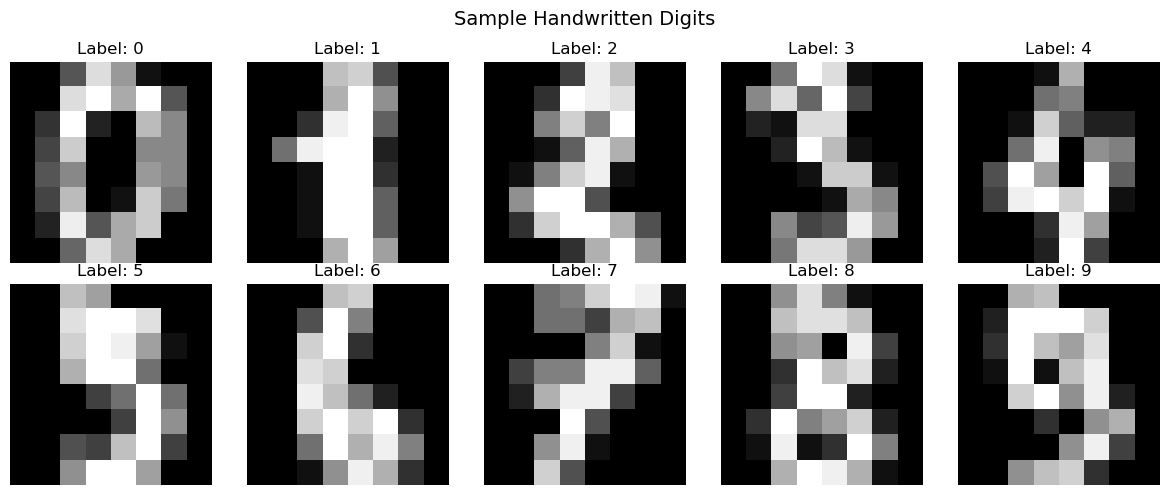

In [51]:
from sklearn.datasets import load_digits

# Load the digits dataset
digits = load_digits()
X_digits, y_digits = digits.data, digits.target

print("Handwritten Digits Dataset")
print("="*50)
print(f"Images: {len(X_digits)}")
print(f"Image size: 8x8 pixels = 64 features")
print(f"Classes: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9")

# Show some examples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {digits.target[i]}')
    ax.axis('off')
plt.suptitle('Sample Handwritten Digits', fontsize=14)
plt.tight_layout()
plt.show()

In [52]:
# Train a digit classifier
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42
)

digit_model = LogisticRegression(max_iter=5000)
digit_model.fit(X_train_d, y_train_d)

accuracy = digit_model.score(X_test_d, y_test_d)
print(f"Accuracy: {accuracy:.1%}")
print(f"\nThe model correctly identifies {accuracy:.1%} of handwritten digits!")

Accuracy: 97.5%

The model correctly identifies 97.5% of handwritten digits!


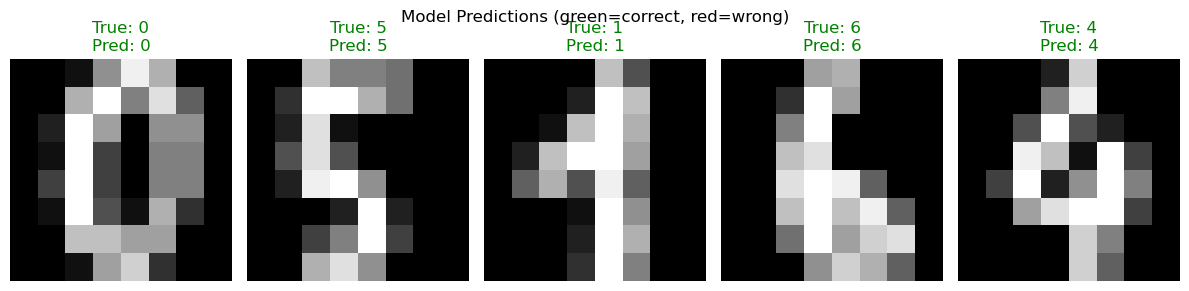

In [53]:
# Show some predictions
sample_indices = [10, 25, 42, 88, 100]
fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for ax, idx in zip(axes, sample_indices):
    img = digits.images[idx]
    true_label = digits.target[idx]
    pred_label = digit_model.predict([digits.data[idx]])[0]
    
    ax.imshow(img, cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
    ax.axis('off')

plt.suptitle('Model Predictions (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.show()

## The Common Thread

Three completely different problems - medicine, finance, handwriting - but the same approach:

| Domain | Input | Output | Stakes |
|--------|-------|--------|--------|
| Medical | Cell measurements | Benign / Malignant | Life or death |
| Finance | Transaction data | Legitimate / Fraud | Money |
| OCR | Pixel values | 0-9 | Convenience |

In every case: collect labeled examples, train a model to find patterns, use those patterns to classify new data. That's the classification pipeline, and it's the same training loop from L3 - gradient descent adjusting weights to minimize a loss function.

But notice something different from regression. In L3, the output was a number (house price). Here, the output is a probability: "87% chance this is malignant" or "99.7% chance this transaction is legitimate." The model needs to express confidence, not just pick a category. That shift - from raw numbers to probabilities - is the core technical challenge we'll solve in this lesson.

Let's work through it step by step using a dataset where the patterns are intuitive.

Now that we've seen classification work across different domains, let's slow down and build a classifier from scratch. We'll use the Titanic dataset - a classic binary classification problem where the patterns are intuitive and the results are meaningful.

We'll build two models of increasing sophistication:
1. **Logistic Regression** - the simplest classifier, basically linear regression with a twist
2. **Neural Network (MLP)** - more powerful, can learn patterns logistic regression can't

Along the way, we'll introduce two new tools: **sigmoid** (turns numbers into probabilities) and **cross-entropy loss** (the loss function for classification). Everything else - gradient descent, the training loop, weight updates - stays exactly the same as L3.

## The Titanic Dataset

The Titanic disaster of 1912 is one of history's most infamous shipwrecks. Of the 2,224 passengers and crew aboard, more than 1,500 died. But survival wasn't random - it was heavily influenced by factors like gender, ticket class, and age. "Women and children first" wasn't just a phrase, it was a real policy that shaped who lived and who died.

Our goal: given information about a passenger (their age, ticket class, gender, fare paid), predict whether they survived. This is a **binary classification** problem - two possible outcomes (survived or died), and we need to find the boundary that separates them.

Why Titanic? Because the features are intuitive. When you see that the model learned to weight "female" heavily toward survival, you'll know it learned something real - not just statistical noise. That interpretability makes it a great dataset for understanding how classifiers work.

Let's look at the actual data:

In [54]:
titanic = pd.read_csv(DATA_PATH / "titanic" / "titanic.csv")
print(f"Dataset: {len(titanic)} passengers")
titanic.head(10)

Dataset: 891 passengers


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


## Visualizing the Classification Problem

Before we build any model, let's see what classification actually looks like visually. We'll plot two features - Age and Fare - and color each passenger by whether they survived (blue) or died (red).

This is the fundamental challenge of classification: you have two groups mixed together in feature space, and you need to find a way to separate them. Look at the plot and ask yourself: **how would you draw a line to separate the blue dots from the red dots?**

Plotting 711 passengers


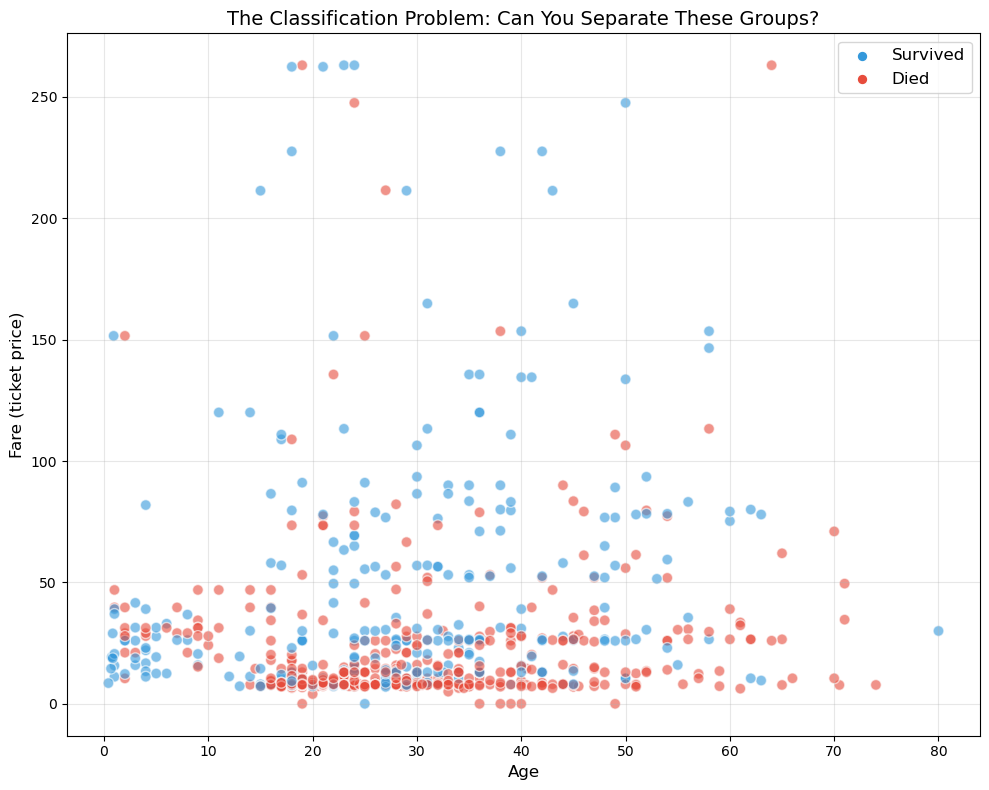

In [55]:
# Get passengers with known age and reasonable fare (for cleaner visualization)
titanic_viz = titanic.dropna(subset=['Age'])
titanic_viz = titanic_viz[titanic_viz['Fare'] < 300]  # Remove a few extreme outliers

ages = titanic_viz['Age'].values
fares = titanic_viz['Fare'].values
survived = titanic_viz['Survived'].values

print(f"Plotting {len(ages)} passengers")
plot_classification_problem(ages, fares, survived)

It's messy, right? The blue and red dots are mixed together - there's no perfect line that separates them completely. That's the reality of most classification problems. Unlike a textbook diagram where two groups are neatly separated, real data overlaps. Some 3rd-class passengers with cheap tickets survived. Some 1st-class passengers with expensive tickets died.

But we can still find a **decision boundary** - a line (or curve) where the model switches its prediction from one class to the other. Everything on one side we predict "survived", everything on the other we predict "died." The boundary won't be perfect, but it can be *useful*.

Let's try drawing one by hand:

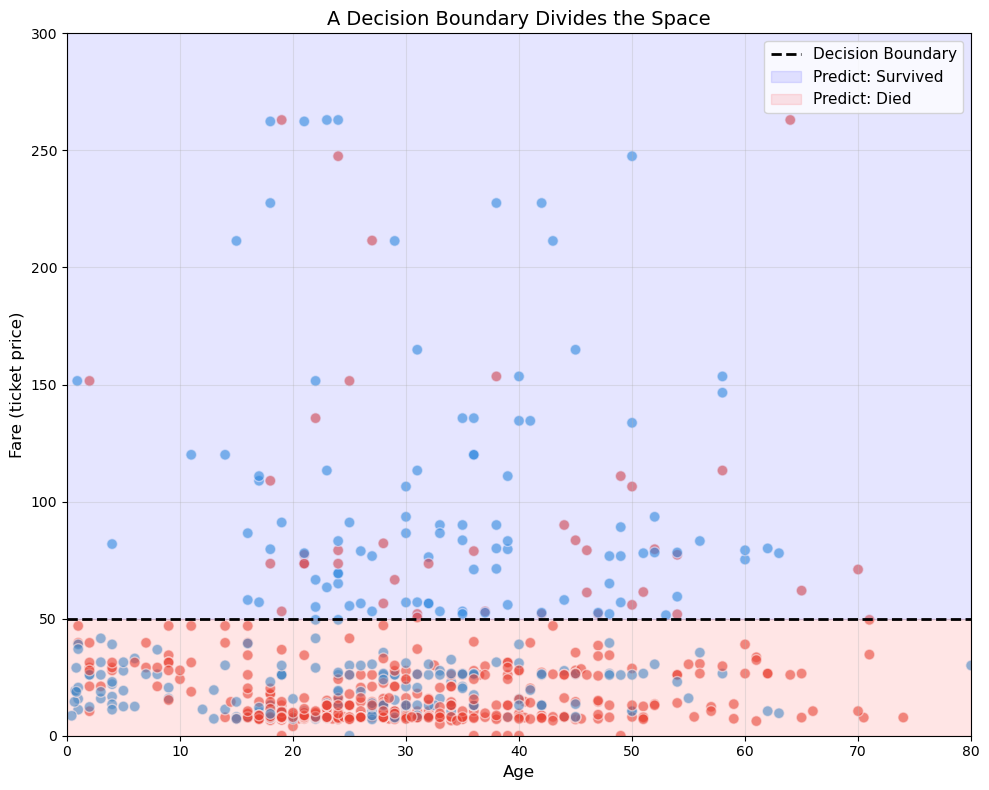

In [56]:
# Let's draw a simple boundary: Fare = 50 (horizontal line)
# Anyone above pays more → predict survived, below → predict died
plot_manual_boundary(ages, fares, survived, slope=0, intercept=50)

This boundary says: "If your fare was above $50, predict survived. Otherwise, predict died."

It's a simple rule, and it captures something real — passengers who paid more for tickets were more likely to survive (they were in better cabins, closer to lifeboats).

But how good is this boundary? Let's measure it:

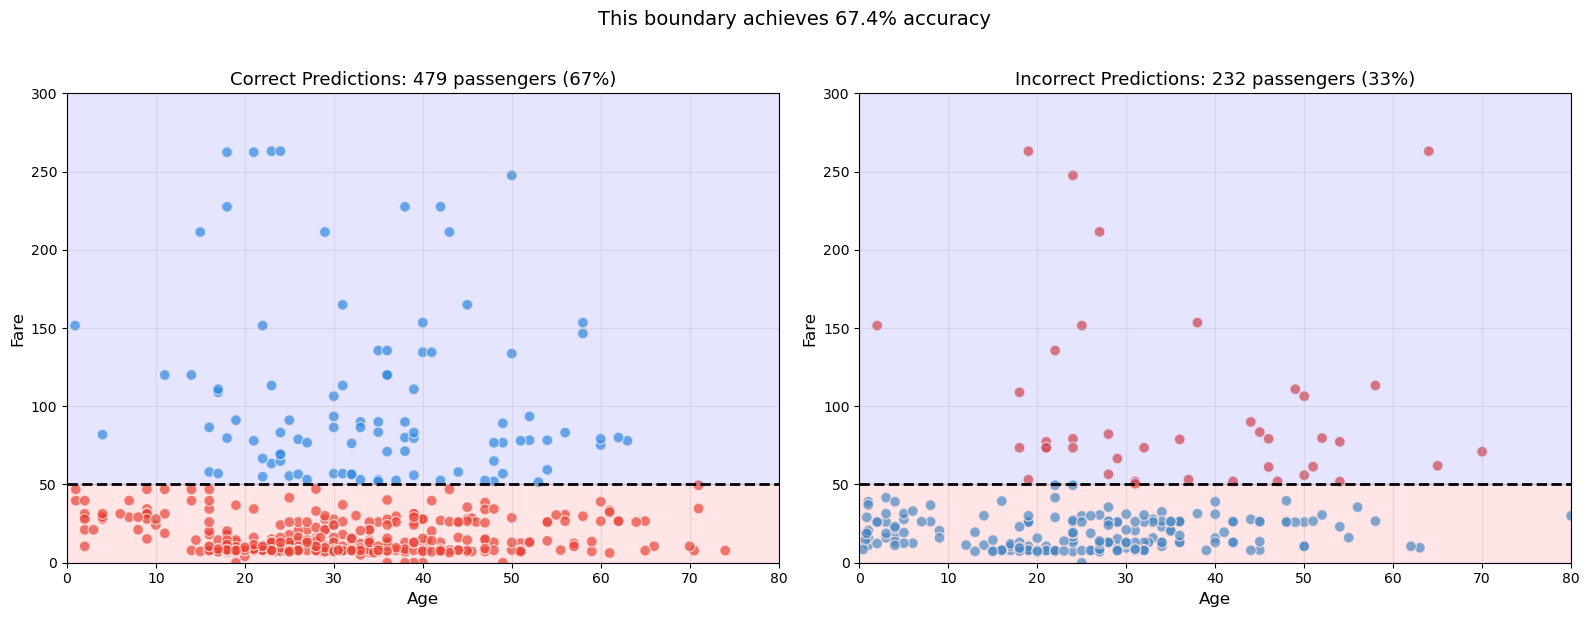

In [57]:
accuracy = plot_boundary_accuracy(ages, fares, survived, slope=0, intercept=50)

## From Manual Rules to Learning

Our simple "fare > $50" boundary gets about 67% accuracy. Better than random guessing, but not by much - guessing "died" for everyone would get ~62% since 62% of passengers died.

We could keep trying different boundaries by hand - fare > $30, age < 10, some diagonal line combining age and fare. But that's tedious and unreliable. We'd be guessing and checking forever, and we'd probably miss patterns that aren't obvious to the human eye.

What we want is what we had in L3: an algorithm that **learns the best boundary from the data automatically**. Give it labeled examples (passengers we know survived or died), and let gradient descent find the weights that draw the best separating line.

But there's a catch. In L3, our model output a number (house price) and we used MSE to measure how wrong it was. Here, the output should be a **probability** - "72% chance this passenger survived." That's a fundamentally different kind of output, and it needs different tools.

Before we build those tools, let's look at what patterns exist in the data that a model could learn from.

## What Predicts Survival?

Let's look at survival rates broken down by different factors. These patterns tell us which features are most useful for separating the groups.

Overall survival rate: 38.4%



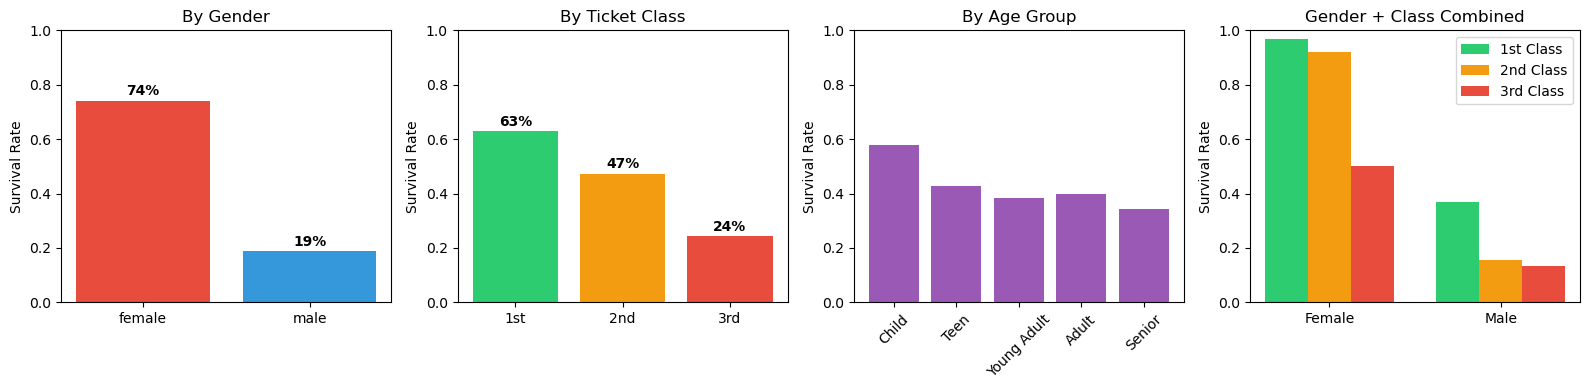

In [58]:
print(f"Overall survival rate: {titanic['Survived'].mean():.1%}\n")
plot_survival_rates(titanic)

Strong patterns emerge:

- **Gender is the strongest signal**: 74% of women survived vs only 19% of men. "Women and children first" wasn't just a policy - it was the dominant factor in who lived and died.
- **Class matters a lot**: 63% of 1st class survived vs 24% of 3rd class. Wealth bought proximity to lifeboats.
- **The combination is even more powerful**: A woman in 1st class had 97% survival; a man in 3rd class had only 14%.

These patterns are exactly what a classifier needs to learn. It should discover: "If female AND 1st class, predict survived with high confidence. If male AND 3rd class, predict died with high confidence." The question is: how do we take these patterns and turn them into a mathematical model that can make predictions on new passengers?

Let's start with something we already know - linear regression - and see why it breaks down for classification.

## Why Not Just Use Linear Regression?

We already know how to fit a line to data using gradient descent. Could we just treat "survived = 1" and "died = 0" as numbers and run linear regression?

Let's try. We'll use just one feature - whether the passenger is male - and fit a regression line predicting survival (0 or 1).

In [59]:
# Prepare simple data: Sex (0=female, 1=male) -> Survived (0 or 1)
titanic_simple = titanic[['Sex', 'Survived']].copy()
titanic_simple['Sex_numeric'] = (titanic_simple['Sex'] == 'male').astype(int)

X_simple = titanic_simple['Sex_numeric'].values
y_simple = titanic_simple['Survived'].values

# Fit linear regression: y = w*x + b
X_mean = X_simple.mean()
y_mean = y_simple.mean()

w = np.sum((X_simple - X_mean) * (y_simple - y_mean)) / np.sum((X_simple - X_mean)**2)
b = y_mean - w * X_mean

print(f"Linear regression: y = {w:.3f}*x + {b:.3f}")
print(f"\nPredictions:")
print(f"  Female (x=0): {b:.3f}")
print(f"  Male (x=1):   {w + b:.3f}")

Linear regression: y = -0.553*x + 0.742

Predictions:
  Female (x=0): 0.742
  Male (x=1):   0.189


The predictions are 0.74 for females and 0.19 for males. Those numbers happen to match the actual survival rates, which feels nice. But there's a fundamental problem hiding here that gets worse with more features.

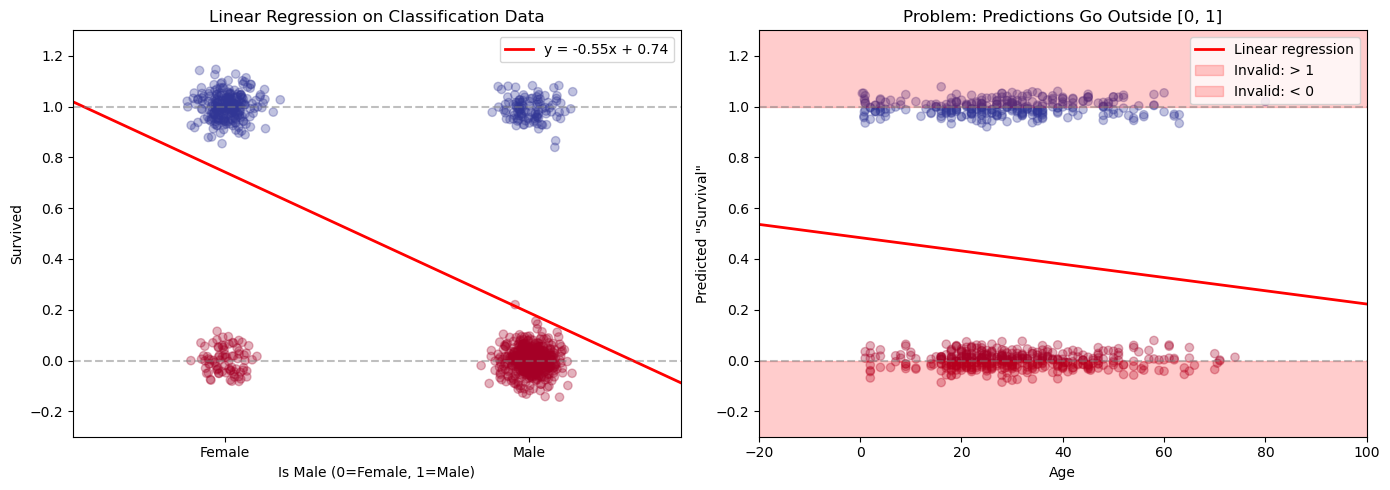

In [ ]:
plot_linear_regression_problem()

# Left one shows linear regression based on categorical / discrete data (e.g male / Female)
# Right one shows if we'd try to plot the relationship between survival rate and age. 

**The problem with linear regression for classification:** The regression line can output any number from negative infinity to positive infinity. But for classification, we need a probability between 0 and 1. What does a prediction of -0.3 mean? Negative 30% chance of survival? Or 1.4 - 140% chance? Those numbers are meaningless as probabilities.

With just one binary feature (male/female), this isn't obvious because the outputs happen to land between 0 and 1. But look at the right plot - as you add more features, the regression line happily extends beyond the valid range. The model has no concept of "this should be a probability."

We need a function that takes any number (the output of our weighted sum) and **squashes** it into the range [0, 1]. That function should be smooth (so gradient descent works), should output exactly 0.5 when it's uncertain, and should approach 0 and 1 at the extremes without ever reaching them. There is such a function, and it's called the **sigmoid**.

## The Sigmoid Function

The **sigmoid function** takes any number - positive, negative, huge, tiny - and maps it to a value between 0 and 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Don't worry about the formula too much. What matters is the shape:

- Feed in a large negative number (like -10) and you get something very close to 0. The model is saying "almost certainly class 0 (died)."
- Feed in a large positive number (like +10) and you get something very close to 1. The model is saying "almost certainly class 1 (survived)."
- Feed in zero and you get exactly 0.5 - the model is maximally uncertain, 50/50.

The S-shape is key: it's steep in the middle (where small changes in the input flip the prediction) and flat at the extremes (where the model is already confident and hard to budge). This makes it perfect for modeling probabilities.

Let's see what it does to some concrete numbers:

In [61]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Test it with some values
test_values = [-10, -5, -2, -1, 0, 1, 2, 5, 10]
print("Input z  →  sigmoid(z)  →  Prediction")
print("-" * 45)
for z in test_values:
    prob = sigmoid(z)
    pred = "Class 1 (survived)" if prob >= 0.5 else "Class 0 (died)"
    print(f"{z:6}   →  {prob:.4f}       →  {pred}")

Input z  →  sigmoid(z)  →  Prediction
---------------------------------------------
   -10   →  0.0000       →  Class 0 (died)
    -5   →  0.0067       →  Class 0 (died)
    -2   →  0.1192       →  Class 0 (died)
    -1   →  0.2689       →  Class 0 (died)
     0   →  0.5000       →  Class 1 (survived)
     1   →  0.7311       →  Class 1 (survived)
     2   →  0.8808       →  Class 1 (survived)
     5   →  0.9933       →  Class 1 (survived)
    10   →  1.0000       →  Class 1 (survived)


And here's what the curve looks like - notice the S-shape that keeps everything between 0 and 1:

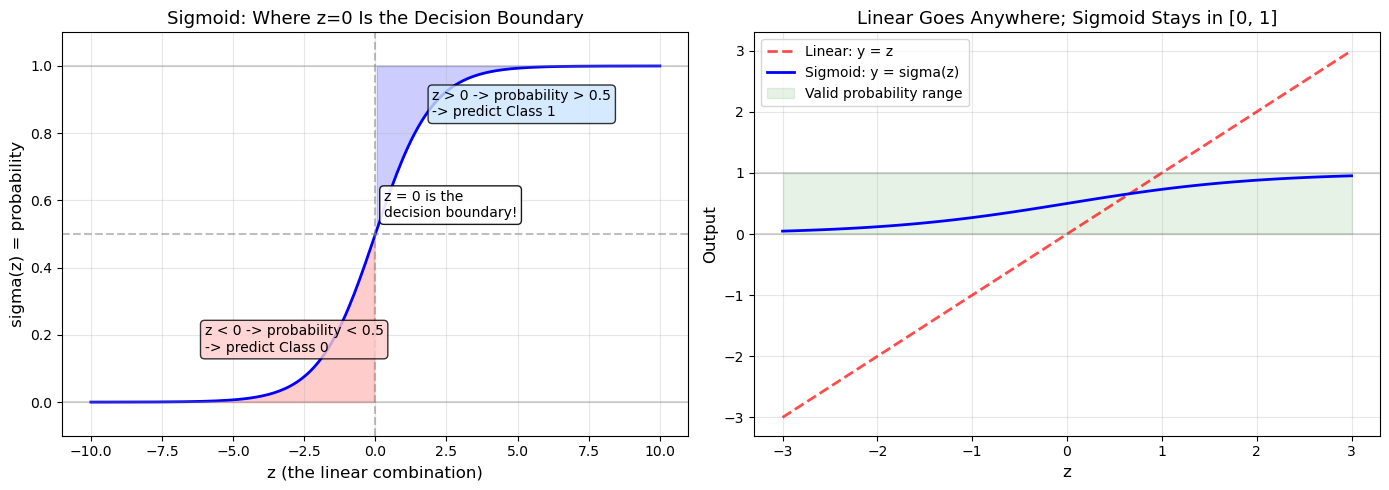

In [62]:
plot_sigmoid()

## Logistic Regression = Linear Model + Sigmoid

Now we have the missing piece. **Logistic regression** is just our linear model from L3 with sigmoid wrapped around it:

1. Compute the weighted sum: `z = w1 * pclass + w2 * sex + w3 * age + w4 * fare + bias`
2. Squash to a probability: `probability = sigmoid(z)`
3. Classify: if probability >= 0.5, predict "survived"

Step 1 is identical to L3 - a dot product of features and weights. Step 2 is new - we pass that number through sigmoid so it becomes a valid probability. Step 3 is just applying a threshold.

The weights still start random. Gradient descent still optimizes them. The training loop is the same: forward pass, compute loss, backward pass, update weights. The only structural change is that sigmoid sits between the linear computation and the output.

But we do need a different loss function. MSE measured "how far off is my number?" Cross-entropy measures "how wrong is my probability?" And it turns out that distinction matters a lot for how well the model learns.

## Preparing the Data

Let's prepare the Titanic data for training. We'll use four key features.

In [63]:
# Select features and handle missing values
features = ['Pclass', 'Sex', 'Age', 'Fare']

# Create a clean dataset
data = titanic[features + ['Survived']].copy()
data['Sex'] = (data['Sex'] == 'male').astype(int)  # Convert to 0/1
data = data.dropna()  # Drop rows with missing Age

print(f"Clean dataset: {len(data)} passengers")
print(f"Features: {features}")
data.head()

Clean dataset: 714 passengers
Features: ['Pclass', 'Sex', 'Age', 'Fare']


,Pclass,Sex,Age,Fare,Survived
0,3,1,22.0,7.2500,0
1,1,0,38.0,71.2833,1
2,3,0,26.0,7.9250,1
3,1,0,35.0,53.1000,1
4,3,1,35.0,8.0500,0


Now we split into training and validation sets (same principle as L3 - never evaluate on data the model trained on) and normalize the features so gradient descent converges smoothly:

In [64]:
# Split into features (X) and target (y)
X = data[features].values
y = data['Survived'].values

# Split into training and validation sets
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features (important for gradient descent)
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_train_norm = (X_train - X_mean) / X_std
X_val_norm = (X_val - X_mean) / X_std

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")

Training set: 571 samples
Validation set: 143 samples


## Training with Gradient Descent (and a New Loss Function)

The training loop is the same as L3 - forward pass, compute loss, compute gradients, update weights. But we need a different loss function.

### Why Not MSE for Classification?

In regression, MSE works great: it measures the squared distance between prediction and target. But for classification, there's a problem. Imagine the model predicts 0.99 (99% confident survived) and the passenger actually died. That's a catastrophically wrong prediction - the model was highly confident and completely wrong. MSE would penalize this as (0.99 - 0)^2 = 0.98. Not great, but not that different from a prediction of 0.8 which gives (0.8 - 0)^2 = 0.64.

We want a loss function that **heavily punishes confident wrong answers**. Being 99% wrong should be dramatically worse than being 80% wrong, not just slightly worse.

### Cross-Entropy Loss

**Cross-entropy loss** (also called **binary cross-entropy** or **BCE**) does exactly this. The formula involves logarithms, which blow up as predictions approach 0:

- Model says 0.99 survived, actually died: loss = -log(1 - 0.99) = -log(0.01) = 4.6 (huge!)
- Model says 0.8 survived, actually died: loss = -log(1 - 0.8) = -log(0.2) = 1.6 (moderate)
- Model says 0.51 survived, actually died: loss = -log(1 - 0.51) = -log(0.49) = 0.7 (small)

See the pattern? As the model gets more confidently wrong, the loss explodes exponentially. This is exactly the incentive structure we want - it forces the model to be honest about its uncertainty. If you're not sure, say 0.5, don't bluff with 0.95.

You don't need to memorize the formula. Just remember: cross-entropy is for classification, MSE is for regression. The gradient computation is different too, but again - PyTorch handles that automatically.

Let's implement it and train:

In [65]:
def logistic_regression_predict(X, w, b):
    """Compute predictions: sigmoid(X @ w + b)"""
    z = X @ w + b
    return sigmoid(z)

def compute_loss(y_true, y_pred):
    """Binary cross-entropy loss"""
    epsilon = 1e-15  # Avoid log(0)
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

def compute_gradients(X, y_true, y_pred):
    """Compute gradients for w and b"""
    m = len(y_true)
    error = y_pred - y_true
    dw = (1/m) * X.T @ error
    db = (1/m) * np.sum(error)
    return dw, db

Now let's run 200 epochs of gradient descent. Watch the loss drop as the model finds better weights:

In [66]:
# Initialize weights
n_features = X_train_norm.shape[1]
w = np.zeros(n_features)
b = 0.0

# Training hyperparameters
learning_rate = 0.1
n_epochs = 200

# Track losses
train_losses = []
val_losses = []

# Training loop
for epoch in range(n_epochs):
    # Forward pass
    y_pred_train = logistic_regression_predict(X_train_norm, w, b)
    y_pred_val = logistic_regression_predict(X_val_norm, w, b)
    
    # Compute loss
    train_loss = compute_loss(y_train, y_pred_train)
    val_loss = compute_loss(y_val, y_pred_val)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # Compute gradients
    dw, db = compute_gradients(X_train_norm, y_train, y_pred_train)
    
    # Update weights (gradient descent!)
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}")

print("\nTraining complete!")

Epoch  50: Train Loss = 0.4793, Val Loss = 0.5204
Epoch 100: Train Loss = 0.4534, Val Loss = 0.5115
Epoch 150: Train Loss = 0.4461, Val Loss = 0.5118
Epoch 200: Train Loss = 0.4430, Val Loss = 0.5126

Training complete!


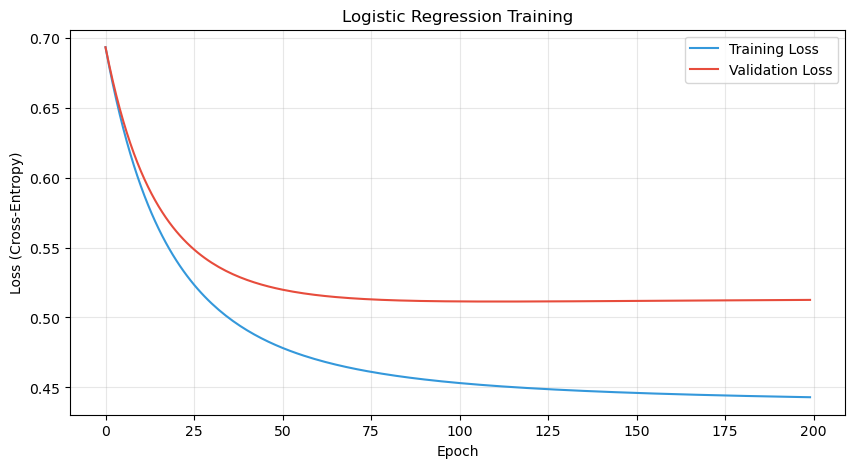

In [67]:
plot_training_curves(train_losses, val_losses)

## Evaluating the Model

The loss dropped during training - that's a good sign. But loss is an abstract number. Let's translate it into something more concrete: how often does the model get the right answer?

We convert each probability to a class prediction using a threshold of 0.5: if the model says "60% chance of survival," we predict survived. If it says "40%," we predict died. Then we count how many predictions match the actual outcomes.

In [68]:
# Make predictions
y_pred_train = logistic_regression_predict(X_train_norm, w, b)
y_pred_val = logistic_regression_predict(X_val_norm, w, b)

# Convert probabilities to class predictions (threshold = 0.5)
y_pred_train_class = (y_pred_train >= 0.5).astype(int)
y_pred_val_class = (y_pred_val >= 0.5).astype(int)

# Calculate accuracy
train_accuracy = np.mean(y_pred_train_class == y_train)
val_accuracy = np.mean(y_pred_val_class == y_val)

print(f"Training Accuracy: {train_accuracy:.1%}")
print(f"Validation Accuracy: {val_accuracy:.1%}")
print(f"\nMuch better than our manual 'fare > $50' boundary ({accuracy:.1%})!")

Training Accuracy: 79.9%
Validation Accuracy: 75.5%

Much better than our manual 'fare > $50' boundary (67.4%)!


## What Did the Model Learn?

Remember, the model started with random weights and gradient descent adjusted them to minimize cross-entropy loss. The final weights tell us what the model discovered about survival patterns. Each weight represents how much that feature influences the model's prediction - a large positive weight pushes toward "survived," a large negative weight pushes toward "died."

Let's see if the model learned the same patterns we noticed earlier in the data exploration:

In [69]:
print("Learned weights (what moves you toward 'survived' side of boundary):")
print("-" * 60)
for feature, weight in zip(features, w):
    if weight > 0:
        effect = "↑ increases survival probability"
    else:
        effect = "↓ decreases survival probability"
    print(f"  {feature:10s}: {weight:+.3f}  {effect}")
print(f"  {'Bias':10s}: {b:+.3f}")

Learned weights (what moves you toward 'survived' side of boundary):
------------------------------------------------------------
  Pclass    : -0.788  ↓ decreases survival probability
  Sex       : -1.190  ↓ decreases survival probability
  Age       : -0.479  ↓ decreases survival probability
  Fare      : +0.183  ↑ increases survival probability
  Bias      : -0.438


The model learned exactly what we expected from the data exploration:

- **Sex** (male=1) has the largest negative weight - being male strongly pushes the prediction toward "died." This is the model discovering "women and children first" from the data alone.
- **Pclass** has a negative weight - higher class number (3rd class = 3) pushes toward "died." Wealthier passengers had better access to lifeboats.
- **Age** has a small negative weight - older passengers were slightly less likely to survive.
- **Fare** has a positive weight - higher fare pushes toward "survived," likely because it correlates with cabin location.

These weights weren't programmed by us. Gradient descent found them by minimizing cross-entropy loss over hundreds of epochs. The model looked at 571 labeled passengers and discovered the historical survival patterns on its own.

This is one of the most satisfying moments in ML: the model's learned weights tell a story that matches real history. But there's a limitation we should see.

## Visualizing the Learned Boundary

Let's train a simpler model using just Age and Fare so we can visualize the decision boundary in 2D. The boundary is the line where the model switches from predicting "died" to predicting "survived."

In [70]:
# Train a 2D model for visualization
X_2d = data[['Age', 'Fare']].values
y_2d = data['Survived'].values

X_train_2d, X_val_2d, y_train_2d, y_val_2d = train_test_split(X_2d, y_2d, test_size=0.2, random_state=42)

# Normalize
X_mean_2d = X_train_2d.mean(axis=0)
X_std_2d = X_train_2d.std(axis=0)
X_train_2d_norm = (X_train_2d - X_mean_2d) / X_std_2d
X_val_2d_norm = (X_val_2d - X_mean_2d) / X_std_2d

# Train
w_2d = np.zeros(2)
b_2d = 0.0

for epoch in range(500):
    y_pred = logistic_regression_predict(X_train_2d_norm, w_2d, b_2d)
    dw, db = compute_gradients(X_train_2d_norm, y_train_2d, y_pred)
    w_2d = w_2d - 0.1 * dw
    b_2d = b_2d - 0.1 * db

val_acc_2d = np.mean((logistic_regression_predict(X_val_2d_norm, w_2d, b_2d) >= 0.5) == y_val_2d)
print(f"2D model validation accuracy: {val_acc_2d:.1%}")

2D model validation accuracy: 62.9%


Let's see that boundary on the scatter plot. The dashed line is where the model switches from predicting "died" to "survived":

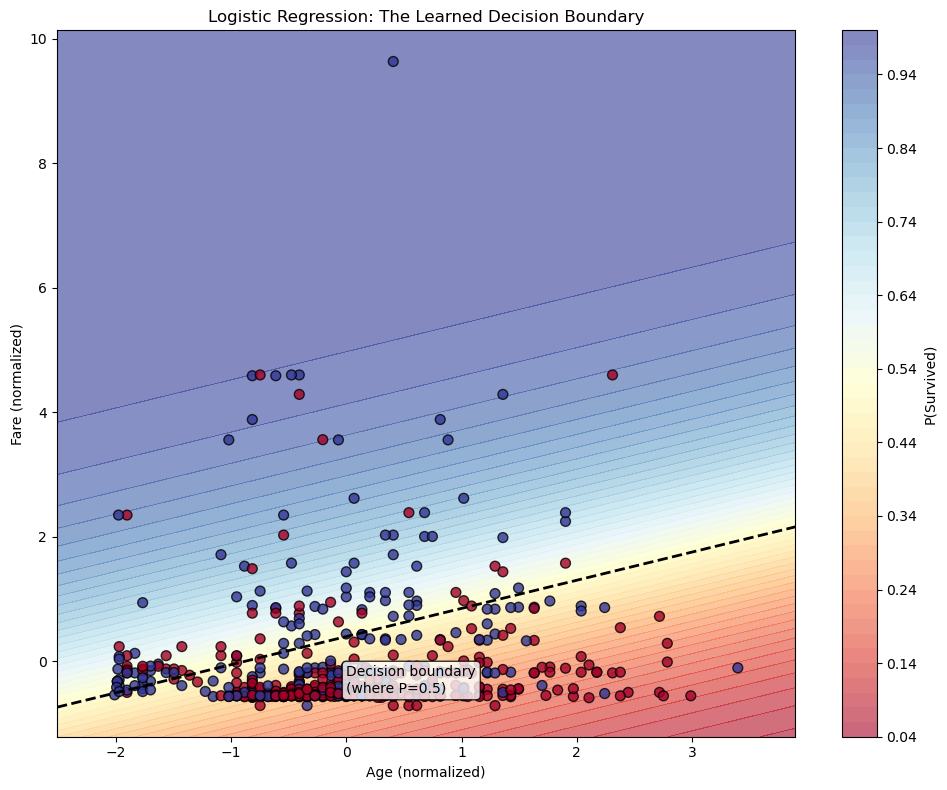

In [71]:
plot_decision_boundary_logistic(
    X_train_2d_norm, y_train_2d, w_2d, b_2d,
    f'Logistic Regression: The Learned Decision Boundary'
)

## The Limitation: Only Straight Boundaries

Look at that decision boundary - it's a **straight line**. That's not a coincidence. Logistic regression computes a weighted sum of features (a linear combination), passes it through sigmoid, and classifies. The decision boundary is where that weighted sum equals zero - which is always a straight line (or a flat plane in higher dimensions).

For the Titanic, this works reasonably well because the survival patterns are roughly linear - richer and female means higher survival. But many real-world problems have patterns that can't be captured by a straight line. Imagine trying to classify whether a point is inside or outside a circle using only a straight boundary. It can't be done.

You *could* get around this by engineering polynomial features - adding Age^2, Fare^2, Age x Fare - and letting the model use those curved features. But then you're manually figuring out which combinations matter. For a problem with 100 features, you'd need to try thousands of combinations.

What if the model could **learn useful feature combinations automatically**? Instead of you deciding "maybe Age^2 matters," the model discovers what transformations of the input are useful on its own?

That's exactly what neural networks do. And the "automatic" part is what makes them so powerful - and honestly, a bit magical at first.

## Enter PyTorch: The Deep Learning Library

To build neural networks, we'll use **PyTorch** — the industry-standard library for deep learning. Before we dive into the code, let's understand what makes it different from NumPy.

**Why not just use NumPy?**

Remember in logistic regression, we computed gradients manually? For a simple model with 5 weights, that was manageable. But neural networks have hundreds or thousands of weights, and the gradients involve chain rules through multiple layers.

PyTorch solves this with **automatic differentiation**: it tracks all operations on your data and automatically computes gradients when you ask. You write the forward pass, PyTorch figures out the backward pass.

**The key concepts:**

| Concept | What it is |
|---------|------------|
| `Tensor` | Like a NumPy array, but can track gradients and run on GPU |
| `nn.Module` | Base class for all neural network components |
| `nn.Linear` | A layer that does `output = input @ weights + bias` |
| `nn.Sequential` | Stack multiple layers in order |
| `loss.backward()` | Compute all gradients automatically |
| `optimizer.step()` | Update all weights using those gradients |

In [72]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"PyTorch version: {torch.__version__}")

# Tensors are like NumPy arrays
numpy_array = np.array([1.0, 2.0, 3.0])
tensor = torch.tensor([1.0, 2.0, 3.0])

print(f"\nNumPy array: {numpy_array}")
print(f"PyTorch tensor: {tensor}")
print(f"Same operations work: tensor * 2 = {tensor * 2}")

PyTorch version: 2.9.1+cu128

NumPy array: [1. 2. 3.]
PyTorch tensor: tensor([1., 2., 3.])
Same operations work: tensor * 2 = tensor([2., 4., 6.])


Tensors look and feel like NumPy arrays, and for basic operations they work the same way. The difference is under the hood: tensors can track every operation performed on them, which is how PyTorch computes gradients automatically. You'll also see `.to(device)` - that moves data to the GPU if one is available, which makes training faster.

Before we build our PyTorch MLP, let's see how easy it is to train a neural network with sklearn - then we'll appreciate what PyTorch gives us:

In [73]:
from sklearn.neural_network import MLPClassifier

# sklearn makes it look easy...
sklearn_mlp = MLPClassifier(hidden_layer_sizes=(16,), max_iter=500, random_state=42)
sklearn_mlp.fit(X_train_norm, y_train)

sklearn_acc = sklearn_mlp.score(X_val_norm, y_val)
print(f"sklearn MLP accuracy: {sklearn_acc:.1%}")
print(f"\nThat was easy! But sklearn hides everything.")
print(f"We can't see the weights updating, can't customize the training loop,")
print(f"can't add GPU acceleration, can't build complex architectures.")
print(f"\nFor real deep learning, we need PyTorch.")

sklearn MLP accuracy: 74.1%

That was easy! But sklearn hides everything.
We can't see the weights updating, can't customize the training loop,
can't add GPU acceleration, can't build complex architectures.

For real deep learning, we need PyTorch.


Scikit-learn's `MLPClassifier` works, but it's a black box. With PyTorch, we'll see exactly what's happening — and that understanding is what lets you build more sophisticated models later.

Let's build the same network in PyTorch:

## The Multi-Layer Perceptron (MLP)

A **Multi-Layer Perceptron** is logistic regression with extra layers in the middle. Instead of going directly from input features to output prediction, the data passes through one or more **hidden layers** first. Each hidden layer transforms the data, creating new intermediate features that the next layer can use.

```
Input (4 features: Pclass, Sex, Age, Fare)
       |
Hidden Layer (16 neurons - learns feature combinations)
       |
Output (1 neuron - probability of survival)
```

The hidden layer is where the magic happens. Each neuron in the hidden layer computes its own weighted sum of the inputs - just like logistic regression - but then passes the result through an activation function (ReLU, not sigmoid). With 16 neurons, the network creates 16 different "views" of the data. Some might learn "young female passenger" as an important combination. Others might learn "3rd class with low fare." The network figures out what combinations are useful for predicting survival.

The output layer then takes those 16 learned features and combines them into a single probability using sigmoid - exactly like logistic regression, but operating on features the network created instead of raw input features.

Let's build one in PyTorch:

In [74]:
class MLP(nn.Module):
    """A simple neural network with one hidden layer."""
    
    def __init__(self, n_features, n_hidden=16):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_features, n_hidden),  # Input -> Hidden
            nn.ReLU(),                         # Activation function - this is super important, but we'll talk more about it later.
            nn.Linear(n_hidden, 1),            # Hidden -> Output
            nn.Sigmoid()                       # Squash to probability - look, we're using sigmoid again! The reason is because we're doing binary classification. There are other activation functions that can do stuff with our output. 
        )
    
    def forward(self, x):
        return self.layers(x)

# Create the model
mlp = MLP(n_features=4, n_hidden=16).to(device)
print(mlp)

MLP(
  (layers): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


Notice the parameter count difference. Logistic regression has just 5 parameters (one weight per feature + bias). The MLP has 97 - all the connections between layers. More parameters means more capacity to learn complex patterns, but also more potential to overfit on small datasets.

Let's convert our data to PyTorch tensors and train:

In [75]:
# How many parameters does each model have?
logistic_params = len(features) + 1  # weights + bias
mlp_params = sum(p.numel() for p in mlp.parameters())

print(f"Logistic regression: {logistic_params} parameters")
print(f"MLP (16 hidden):     {mlp_params} parameters")
print(f"\nThe MLP has {mlp_params // logistic_params}x more parameters — more capacity to learn complex patterns.")

Logistic regression: 5 parameters
MLP (16 hidden):     97 parameters

The MLP has 19x more parameters — more capacity to learn complex patterns.


In [76]:
# Convert our numpy data to PyTorch tensors
X_train_t = torch.FloatTensor(X_train_norm).to(device)
y_train_t = torch.FloatTensor(y_train).reshape(-1, 1).to(device)
X_val_t = torch.FloatTensor(X_val_norm).to(device)
y_val_t = torch.FloatTensor(y_val).reshape(-1, 1).to(device)

print(f"Training data: {X_train_t.shape}")
print(f"Validation data: {X_val_t.shape}")

Training data: torch.Size([571, 4])
Validation data: torch.Size([143, 4])


## Training the MLP

The training loop is the same pattern we've been using since L3. The only difference in PyTorch is the syntax: `loss.backward()` computes all gradients automatically, and `optimizer.step()` updates all weights. No manual gradient formulas needed - PyTorch figures out the math for us, even through multiple layers.

In [77]:
# Fresh model
mlp = MLP(n_features=4, n_hidden=16).to(device)

# Loss function and optimizer
loss_fn = nn.BCELoss()  # Binary cross-entropy (same as we used before)
optimizer = optim.Adam(mlp.parameters(), lr=0.01)

# Track losses
mlp_train_losses = []
mlp_val_losses = []

# Training loop
n_epochs = 200

for epoch in range(n_epochs):
    # Forward pass
    mlp.train()
    y_pred = mlp(X_train_t)
    loss = loss_fn(y_pred, y_train_t)
    
    # Backward pass
    optimizer.zero_grad()  # Clear old gradients
    loss.backward()        # Compute new gradients
    optimizer.step()       # Update weights
    
    # Track losses
    mlp_train_losses.append(loss.item())
    
    mlp.eval()
    with torch.no_grad():
        val_loss = loss_fn(mlp(X_val_t), y_val_t)
        mlp_val_losses.append(val_loss.item())
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: Train Loss = {loss.item():.4f}, Val Loss = {val_loss.item():.4f}")

print("\nTraining complete!")

Epoch  50: Train Loss = 0.4225, Val Loss = 0.5004
Epoch 100: Train Loss = 0.4062, Val Loss = 0.4926
Epoch 150: Train Loss = 0.3995, Val Loss = 0.4878
Epoch 200: Train Loss = 0.3904, Val Loss = 0.4765

Training complete!


In [78]:
# Evaluate the MLP
mlp.eval()
with torch.no_grad():
    mlp_train_pred = (mlp(X_train_t) >= 0.5).float()
    mlp_val_pred = (mlp(X_val_t) >= 0.5).float()
    
    mlp_train_acc = (mlp_train_pred == y_train_t).float().mean().item()
    mlp_val_acc = (mlp_val_pred == y_val_t).float().mean().item()

print("="*55)
print("MODEL COMPARISON")
print("="*55)
print(f"{'Model':<25} {'Train Acc':<15} {'Val Acc':<15}")
print("-"*55)
print(f"{'Logistic Regression':<25} {train_accuracy:<15.1%} {val_accuracy:<15.1%}")
print(f"{'MLP (16 hidden neurons)':<25} {mlp_train_acc:<15.1%} {mlp_val_acc:<15.1%}")
print("="*55)

MODEL COMPARISON
Model                     Train Acc       Val Acc        
-------------------------------------------------------
Logistic Regression       79.9%           75.5%          
MLP (16 hidden neurons)   83.0%           76.2%          


## The MLP's Decision Boundary

Let's see what the MLP learns compared to logistic regression. We'll train on the same 2D data (Age and Fare) and visualize both decision boundaries side by side.

In [79]:
# Train MLP on 2D data for visualization
X_train_2d_t = torch.FloatTensor(X_train_2d_norm).to(device)
y_train_2d_t = torch.FloatTensor(y_train_2d).reshape(-1, 1).to(device)
X_val_2d_t = torch.FloatTensor(X_val_2d_norm).to(device)
y_val_2d_t = torch.FloatTensor(y_val_2d).reshape(-1, 1).to(device)

mlp_2d = MLP(n_features=2, n_hidden=16).to(device)
optimizer_2d = optim.Adam(mlp_2d.parameters(), lr=0.01)

for epoch in range(500):
    mlp_2d.train()
    pred = mlp_2d(X_train_2d_t)
    loss = loss_fn(pred, y_train_2d_t)
    optimizer_2d.zero_grad()
    loss.backward()
    optimizer_2d.step()

mlp_2d.eval()
with torch.no_grad():
    mlp_2d_val_acc = ((mlp_2d(X_val_2d_t) >= 0.5).float() == y_val_2d_t).float().mean().item()

print(f"MLP (2D) validation accuracy: {mlp_2d_val_acc:.1%}")

MLP (2D) validation accuracy: 67.1%


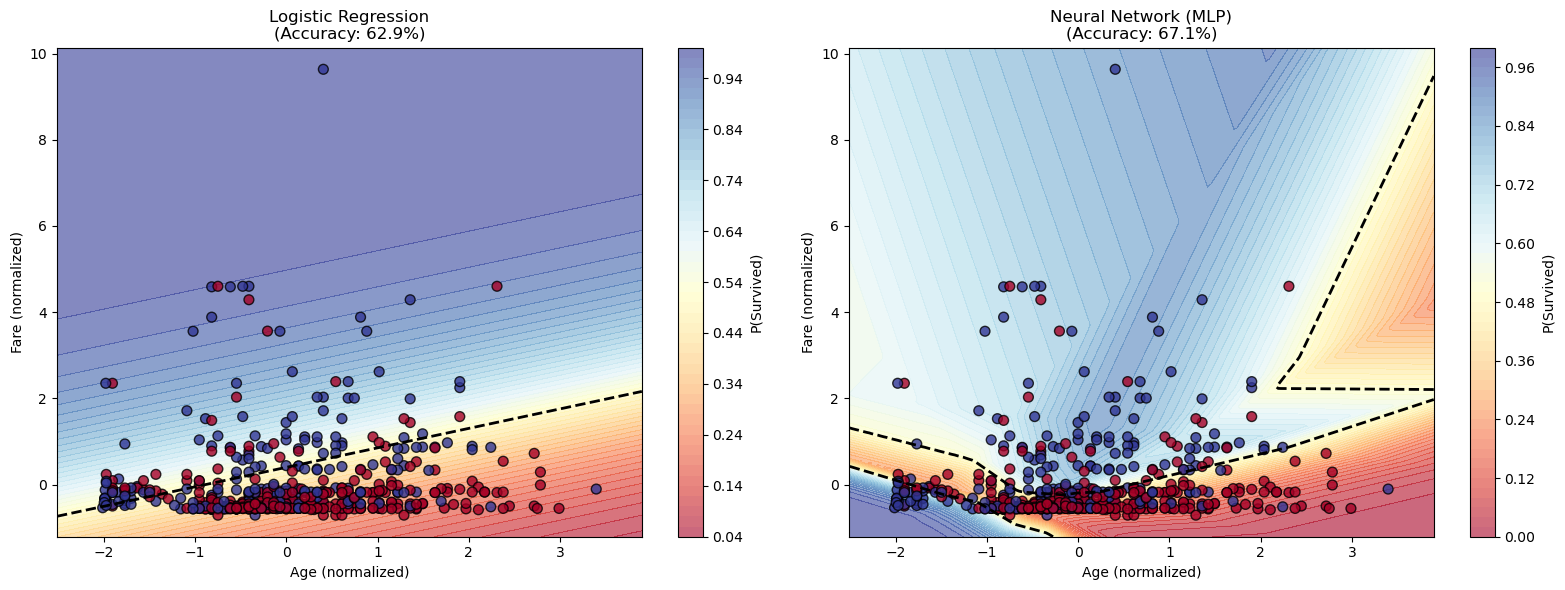

Left: Logistic regression with raw features — straight boundary.
Right: Neural network — learns its own features, can capture more complex patterns.


In [80]:
plot_comparison(
    X_train_2d_norm, y_train_2d, w_2d, b_2d, mlp_2d,
    'Logistic Regression', 'Neural Network (MLP)',
    val_acc_2d, mlp_2d_val_acc
)

print("Left: Logistic regression with raw features — straight boundary.")
print("Right: Neural network — learns its own features, can capture more complex patterns.")

## Why Does the MLP Learn Curved Boundaries?

This is the key question. Logistic regression draws a straight line. The MLP draws curves. What changed?

The answer: the hidden layer **creates new features** from the inputs. It takes the raw features (Age, Fare) and transforms them into 16 new numbers - each one a different weighted combination of the inputs, passed through ReLU. These 16 new features are not the same as the original inputs. They're *learned representations* - intermediate values that the network discovered are useful for this specific task.

Think of it this way: if you gave logistic regression the features [Age, Fare], it can only draw a straight line in that 2D space. But the hidden layer transforms [Age, Fare] into 16 new features. The output layer then does logistic regression in that 16-dimensional space - and a straight line in 16 dimensions, when projected back to the original 2D space, becomes a curve.

The network doesn't know it's learning curves. It's just doing weighted sums and ReLU, over and over. But the result is a model that can fit much more complex patterns. We'll explore exactly how this works - tracing actual numbers through each layer - in the next lesson.

### The Role of ReLU

Between layers, we apply **ReLU** (Rectified Linear Unit): it keeps positive values unchanged and sets negative values to zero. That's it. `ReLU(x) = max(0, x)`.

Why does something so simple matter so much? Because without it, stacking two linear layers is the same as having one linear layer. If layer 1 computes `y = Ax + b` and layer 2 computes `z = Cy + d`, then together they compute `z = C(Ax + b) + d = CAx + Cb + d` - which is just another linear function. You'd get the same result with a single layer. No matter how many linear layers you stack, the result is still linear. Still straight boundaries.

ReLU breaks the linearity. By zeroing out negative values, it introduces "bends" in the function. Those bends are what allow the network to learn curves instead of just straight lines. It's a simple operation, but it's the ingredient that makes deep learning work.

We'll explore ReLU more in the next lesson when we trace actual numbers through the network. For now, just know: ReLU is why the MLP can learn patterns that logistic regression can't.

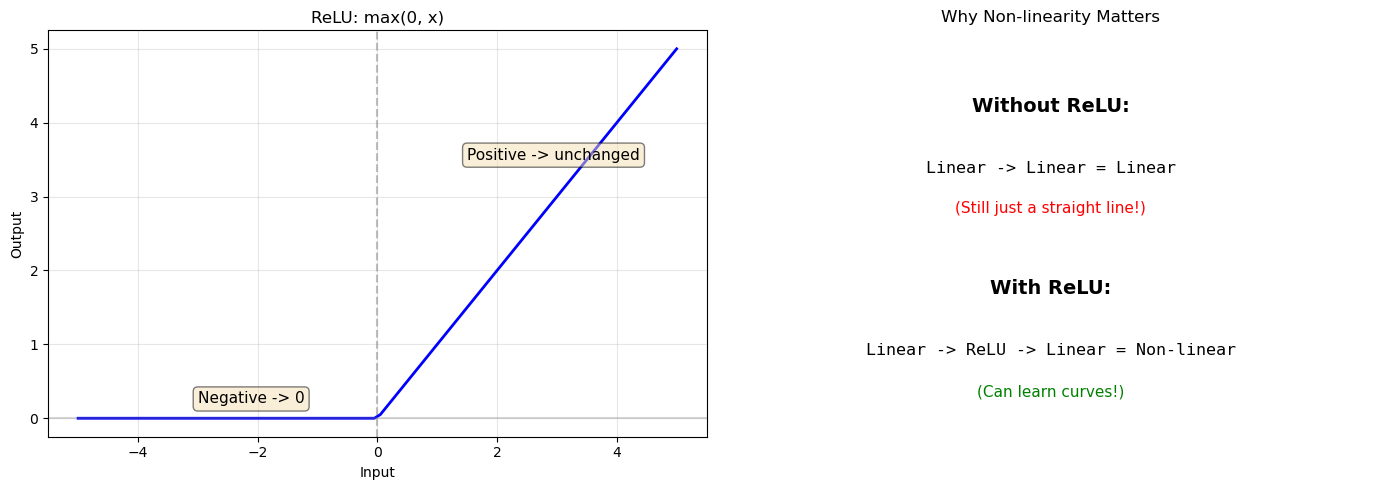

In [81]:
plot_relu()

### Quick Terminology Recap

We've introduced several new terms in this lesson. Here's a quick reference:

- **Layer** - a transformation step. Our MLP has three: input (4 features), hidden (16 neurons), output (1 probability)
- **Neuron** - one unit in a layer. Each neuron computes a weighted sum of its inputs and applies an activation function. Our hidden layer has 16 neurons, meaning it creates 16 different feature combinations.
- **Activation function** - the non-linear function applied after a layer's weighted sum. ReLU between hidden layers (introduces curves), Sigmoid at the output (produces probabilities).
- **Architecture** - the structure of a network: how many layers, how many neurons per layer, which activations. Ours is `Linear(4,16) -> ReLU -> Linear(16,1) -> Sigmoid`.

The next lesson goes much deeper into what each of these actually computes with real numbers.

## What's Happening Inside?

We've seen that the MLP works — it learns curved boundaries that logistic regression can't. But we've been treating it as a black box.

What actually happens when data flows through those layers? What do the hidden neurons compute? How does `loss.backward()` figure out which weights to blame?

**The next lesson opens the black box.** We'll:
- Trace real numbers through each layer, watching them transform
- Visualize what each neuron learns to detect
- Understand how gradients flow backward to update weights
- See the complete training loop in slow motion

You'll come away understanding not just *that* neural networks work, but *how* they work.

## Summary

**What we learned:**

1. **Classification** = predicting which group something belongs to (not a number)

2. **Logistic regression** = weighted sum → sigmoid → threshold. Simple, interpretable, but with basic features gives straight boundaries.

3. **Neural networks (MLPs)** = add hidden layers that automatically learn useful feature combinations. Can learn more complex patterns without manual feature engineering.

**The key insight:** Neural networks learn what features matter, instead of us having to figure it out manually.

**Next lesson:** We'll open the black box and see what's actually happening inside the neural network.

In [82]:
print("="*55)
print("RESULTS")
print("="*55)
print(f"{'Model':<25} {'Validation Accuracy':<20}")
print("-"*45)
print(f"{'Logistic Regression':<25} {val_accuracy:<20.1%}")
print(f"{'MLP (16 hidden neurons)':<25} {mlp_val_acc:<20.1%}")
print()
print("Both work! The MLP is slightly better here.")
print("The real advantage of neural networks shows on")
print("more complex data (images, text) where manual")
print("feature engineering would be impractical.")

RESULTS
Model                     Validation Accuracy 
---------------------------------------------
Logistic Regression       75.5%               
MLP (16 hidden neurons)   76.2%               

Both work! The MLP is slightly better here.
The real advantage of neural networks shows on
more complex data (images, text) where manual
feature engineering would be impractical.


<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
© 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>